# Version 6.3 : LightGBM Survival Model (Simple)

**Modèle** : LightGBM pour analyse de survie
- Alternative à XGBoost, souvent plus rapide
- Objectif : Régression sur log(temps de survie)
- Méthode : AFT (Accelerated Failure Time)

**Objectif** : Tester performance LightGBM vs XGBoost (C-index > 0.74)

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported")

✓ Libraries imported


## 2. Configuration

In [2]:
DATA_PATH = r"C:\Users\guill\Desktop\Data Challenge QRT\Data-Challenge-Prediction-de-Survie"

# LightGBM parameters (conservative start)
LGBM_PARAMS = {
    'objective': 'regression',
    'metric': 'l2',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 5,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'verbose': -1,
    'n_jobs': -1,
    'random_state': 42
}

print("✓ Configuration loaded")
print(f"  Learning rate: {LGBM_PARAMS['learning_rate']}")
print(f"  Max depth: {LGBM_PARAMS['max_depth']}")

✓ Configuration loaded
  Learning rate: 0.05
  Max depth: 5


## 3. Data Loading & Feature Engineering

In [3]:
# Load data
clinical_train = pd.read_csv(f"{DATA_PATH}\\X_train\\clinical_train.csv")
target_train = pd.read_csv(f"{DATA_PATH}\\target_train.csv")
molecular_train = pd.read_csv(f"{DATA_PATH}\\X_train\\molecular_train.csv")

print("✓ Data loaded")

✓ Data loaded


In [4]:
# Feature engineering functions (from V6.1)
def create_cytogenetic_features(clinical_df):
    cyto_features = pd.DataFrame(index=clinical_df['ID'])
    cyto_col = clinical_df.set_index('ID')['CYTOGENETICS'].fillna('')
    cyto_features['cyto_del_count'] = cyto_col.str.count(r'del\(')
    cyto_features['cyto_has_del'] = (cyto_features['cyto_del_count'] > 0).astype(int)
    cyto_features['cyto_transloc_count'] = cyto_col.str.count(r't\(')
    cyto_features['cyto_has_transloc'] = (cyto_features['cyto_transloc_count'] > 0).astype(int)
    cyto_features['cyto_inv_count'] = cyto_col.str.count(r'inv\(')
    cyto_features['cyto_has_inv'] = (cyto_features['cyto_inv_count'] > 0).astype(int)
    cyto_features['cyto_gain_count'] = cyto_col.str.count(r'\+')
    cyto_features['cyto_has_gain'] = (cyto_features['cyto_gain_count'] > 0).astype(int)
    cyto_features['cyto_loss_count'] = cyto_col.str.count(r'-[0-9XY]')
    cyto_features['cyto_has_loss'] = (cyto_features['cyto_loss_count'] > 0).astype(int)
    cyto_features['cyto_other_count'] = cyto_col.str.count(r'add\(|ins\(|dup\(')
    cyto_features['cyto_total_anomalies'] = (
        cyto_features['cyto_del_count'] + cyto_features['cyto_transloc_count'] + 
        cyto_features['cyto_inv_count'] + cyto_features['cyto_gain_count'] + 
        cyto_features['cyto_loss_count'] + cyto_features['cyto_other_count']
    )
    cyto_features['cyto_normal'] = cyto_col.str.match(r'^46,(xx|xy)(\[\d+\])?$', case=False).astype(int)
    cyto_features['cyto_complex'] = (
        (cyto_features['cyto_total_anomalies'] >= 3) | 
        cyto_col.str.contains('complex', case=False, na=False)
    ).astype(int)
    chromosomes = [str(i) for i in range(1, 23)] + ['X', 'Y']
    for chrom in chromosomes:
        pattern = rf'(\b|[,\(]){chrom}([,;:\)\[]|[pq])'
        cyto_features[f'cyto_chr{chrom}_affected'] = cyto_col.str.contains(
            pattern, case=False, na=False, regex=True
        ).astype(int)
    cyto_features['cyto_monosomy7'] = cyto_col.str.contains(r'-7[^0-9]|^45.*-7', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_trisomy8'] = cyto_col.str.contains(r'\+8[^0-9]|^47.*\+8', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_del5q'] = cyto_col.str.contains(r'del\(5\)\(q', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_del20q'] = cyto_col.str.contains(r'del\(20\)\(q', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_chr3_abnormal'] = cyto_col.str.contains(r'(del|t|inv)\(3[;,:\)]', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_chr7_abnormal'] = cyto_col.str.contains(r'(del|t|inv)\(7[;,:\)]', case=False, na=False, regex=True).astype(int)
    return cyto_features.fillna(0)

def create_molecular_features(molecular_df, patient_ids, top_n_genes=20):
    mol_features = pd.DataFrame({'ID': patient_ids})
    mutation_counts = molecular_df.groupby('ID').size().to_frame('mutation_count_total')
    mol_features = mol_features.merge(mutation_counts, on='ID', how='left')
    vaf_stats = molecular_df.groupby('ID')['VAF'].agg([
        ('vaf_mean', 'mean'), ('vaf_max', 'max'), ('vaf_sum', 'sum')
    ]).reset_index()
    mol_features = mol_features.merge(vaf_stats, on='ID', how='left')
    effect_counts = molecular_df.groupby(['ID', 'EFFECT']).size().unstack(fill_value=0)
    effect_counts.columns = [f'effect_{col}' for col in effect_counts.columns]
    mol_features = mol_features.merge(effect_counts.reset_index(), on='ID', how='left')
    top_genes_list = molecular_df['GENE'].value_counts().head(top_n_genes).index.tolist()
    for gene in top_genes_list:
        gene_mutations = molecular_df[molecular_df['GENE'] == gene].groupby('ID').size()
        mol_features[f'gene_{gene}_count'] = mol_features['ID'].map(gene_mutations)
        gene_present = molecular_df[molecular_df['GENE'] == gene]['ID'].unique()
        mol_features[f'gene_{gene}_present'] = mol_features['ID'].isin(gene_present).astype(int)
    feature_cols = [col for col in mol_features.columns if col != 'ID']
    mol_features[feature_cols] = mol_features[feature_cols].fillna(0)
    return mol_features.set_index('ID')

def create_advanced_features(X_df):
    X_adv = X_df.copy()
    X_adv['blast_to_wbc'] = X_adv['BM_BLAST'] / (X_adv['WBC'] + 1)
    X_adv['monocyte_ratio'] = X_adv['MONOCYTES'] / (X_adv['WBC'] + 1)
    X_adv['anc_ratio'] = X_adv['ANC'] / (X_adv['WBC'] + 1)
    X_adv['platelet_to_blast'] = X_adv['PLT'] / (X_adv['BM_BLAST'] + 1)
    X_adv['hb_to_plt'] = X_adv['HB'] / (X_adv['PLT'] + 1)
    X_adv['vaf_mutation_burden'] = X_adv['vaf_mean'] * X_adv['mutation_count_total']
    X_adv['vaf_per_mutation'] = X_adv['vaf_sum'] / (X_adv['mutation_count_total'] + 1)
    X_adv['cytogenetic_risk_score'] = (
        X_adv['cyto_complex'] * 3 + X_adv['cyto_chr7_affected'] * 2 + 
        X_adv['cyto_del5q'] * 1.5 + X_adv['cyto_loss_count'] * 0.5
    )
    X_adv['blast_cytogenetic_risk'] = X_adv['BM_BLAST'] * X_adv['cytogenetic_risk_score']
    X_adv['blast_to_mutation'] = X_adv['BM_BLAST'] / (X_adv['mutation_count_total'] + 1)
    X_adv['wbc_plt_index'] = X_adv['WBC'] * X_adv['PLT'] / 1000
    X_adv['blast_hb_ratio'] = X_adv['BM_BLAST'] / (X_adv['HB'] + 1)
    X_adv['monocyte_blast_ratio'] = X_adv['MONOCYTES'] / (X_adv['BM_BLAST'] + 1)
    X_adv['mutation_per_vaf'] = X_adv['mutation_count_total'] / (X_adv['vaf_mean'] + 0.01)
    X_adv['cyto_anomaly_density'] = X_adv['cyto_total_anomalies'] / (X_adv['cyto_total_anomalies'].max() + 1)
    X_adv['blast_mutation_interaction'] = X_adv['BM_BLAST'] * X_adv['mutation_count_total']
    X_adv['blast_vaf_interaction'] = X_adv['BM_BLAST'] * X_adv['vaf_mean']
    X_adv['blast_cyto_complex'] = X_adv['BM_BLAST'] * X_adv['cyto_complex']
    X_adv['tp53_blast'] = X_adv['gene_TP53_present'] * X_adv['BM_BLAST']
    X_adv['runx1_mutation_burden'] = X_adv['gene_RUNX1_count'] * X_adv['mutation_count_total']
    X_adv['nras_vaf'] = X_adv['gene_NRAS_present'] * X_adv['vaf_mean']
    X_adv['cyto_mutation_interaction'] = X_adv['cyto_total_anomalies'] * X_adv['mutation_count_total']
    X_adv['chr7_blast'] = X_adv['cyto_chr7_affected'] * X_adv['BM_BLAST']
    X_adv['vaf_cyto_burden'] = X_adv['vaf_sum'] * X_adv['cyto_total_anomalies']
    X_adv['vaf_tp53'] = X_adv['vaf_mean'] * X_adv['gene_TP53_present']
    X_adv['log_wbc'] = np.log1p(X_adv['WBC'])
    X_adv['log_plt'] = np.log1p(X_adv['PLT'])
    X_adv['log_blast'] = np.log1p(X_adv['BM_BLAST'])
    X_adv['log_mutation_count'] = np.log1p(X_adv['mutation_count_total'])
    X_adv['log_vaf_sum'] = np.log1p(X_adv['vaf_sum'])
    return X_adv

# Create features
cyto_features_train = create_cytogenetic_features(clinical_train)
train_patient_ids = clinical_train['ID'].unique()
mol_features_train = create_molecular_features(molecular_train, train_patient_ids)

target_clean = target_train.dropna(subset=['OS_YEARS', 'OS_STATUS']).copy()
target_clean['OS_STATUS'] = target_clean['OS_STATUS'].astype(bool)
target_clean = target_clean.set_index('ID')

clinical_train_clean = clinical_train[clinical_train['ID'].isin(target_clean.index)].copy()
clinical_train_clean = clinical_train_clean.set_index('ID').loc[target_clean.index]

numeric_features = ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']
X_numeric = clinical_train_clean[numeric_features].copy()
center_encoded = pd.get_dummies(clinical_train_clean['CENTER'], prefix='CENTER', drop_first=True)
X_clinical = pd.concat([X_numeric, center_encoded], axis=1)

mol_features_train_aligned = mol_features_train.reindex(X_clinical.index, fill_value=0)
cyto_features_train_aligned = cyto_features_train.reindex(X_clinical.index, fill_value=0)
X_all_base = pd.concat([X_clinical, mol_features_train_aligned, cyto_features_train_aligned], axis=1)
X_all = create_advanced_features(X_all_base)

y_surv = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_clean)

print(f"✓ Features created: {X_all.shape[1]} total")

✓ Features created: 162 total


## 4. Preprocessing

In [5]:
# Impute missing values
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_all),
    index=X_all.index,
    columns=X_all.columns
)

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X_imputed, y_surv, test_size=0.3, random_state=42,
    stratify=target_clean['OS_STATUS'].astype(int)
)

print(f"✓ Split: {len(X_train)} train, {len(X_val)} val")

✓ Split: 2221 train, 952 val


## 5. Train LightGBM Model

In [6]:
# Prepare target (log survival time)
y_train_lgbm = np.log1p(y_train['OS_YEARS'])
y_val_lgbm = np.log1p(y_val['OS_YEARS'])

# Create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train_lgbm)
val_data = lgb.Dataset(X_val, label=y_val_lgbm, reference=train_data)

print("Training LightGBM model...")

# Train with early stopping
lgbm_model = lgb.train(
    LGBM_PARAMS,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

print(f"\n✓ Training complete")
print(f"  Best iteration: {lgbm_model.best_iteration}")

Training LightGBM model...
[100]	train's l2: 0.227711	val's l2: 0.36232
[200]	train's l2: 0.186276	val's l2: 0.359328

✓ Training complete
  Best iteration: 200


## 6. Evaluation

In [7]:
# Predictions (negate because higher log(time) = lower risk)
y_pred_train = -lgbm_model.predict(X_train, num_iteration=lgbm_model.best_iteration)
y_pred_val = -lgbm_model.predict(X_val, num_iteration=lgbm_model.best_iteration)

# Calculate C-index
c_index_train = concordance_index_censored(
    y_train['OS_STATUS'], y_train['OS_YEARS'], y_pred_train
)[0]

c_index_val = concordance_index_censored(
    y_val['OS_STATUS'], y_val['OS_YEARS'], y_pred_val
)[0]

print("=" * 60)
print("EVALUATION RESULTS")
print("=" * 60)
print(f"C-index (Train): {c_index_train:.4f}")
print(f"C-index (Val):   {c_index_val:.4f}")
print("=" * 60)

EVALUATION RESULTS
C-index (Train): 0.8153
C-index (Val):   0.6889


## 7. Feature Importance

Top 20 Most Important Features:
                   feature  importance
                        HB  365.151358
 cyto_mutation_interaction  315.603306
                       PLT  276.481910
         platelet_to_blast  260.914487
                 CENTER_KI  213.449228
          mutation_per_vaf  158.612327
                       WBC  153.432569
                   vaf_sum  142.813241
                 MONOCYTES  140.025538
       vaf_mutation_burden  138.148506
    blast_cytogenetic_risk  137.307181
           vaf_cyto_burden  135.262280
blast_mutation_interaction  133.922742
             wbc_plt_index  120.393015
                   vaf_max  110.192028
      monocyte_blast_ratio  104.071870
                CENTER_ROM  102.186248
                 CENTER_PV  101.555212
                  vaf_mean   99.033563
                       ANC   92.212787


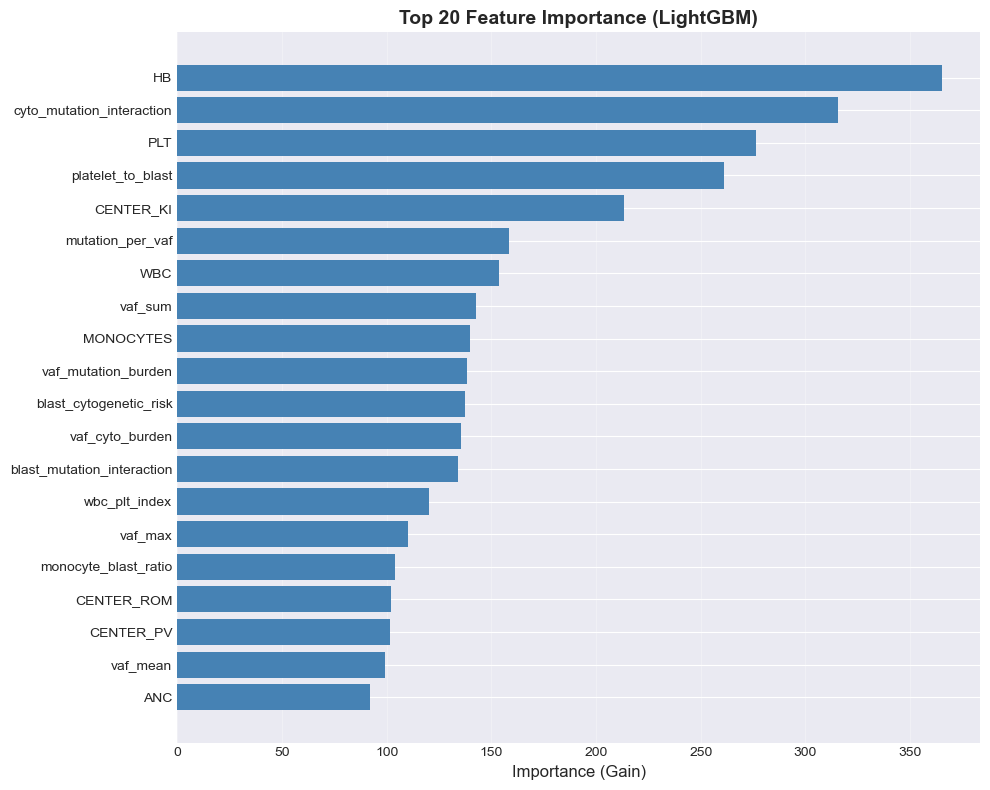

In [8]:
# Get feature importance
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgbm_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features:")
print(importance_df.head(20).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
top_20 = importance_df.head(20)
ax.barh(range(len(top_20)), top_20['importance'], color='steelblue')
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['feature'])
ax.invert_yaxis()
ax.set_xlabel('Importance (Gain)', fontsize=12)
ax.set_title('Top 20 Feature Importance (LightGBM)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 8. Comparison with Other Models

In [ ]:
comparison = pd.DataFrame([
    {'Model': 'V4 RSF', 'C-index': 0.7404, 'Method': 'Random Survival Forest'},
    {'Model': 'V6.1 XGBoost', 'C-index': 0.7413, 'Method': 'XGBoost Survival (Cox)'},
    {'Model': 'V6.3 LightGBM', 'C-index': c_index_val, 'Method': 'LightGBM (AFT)'},
])

print("\n" + "=" * 60)
print("PERFORMANCE COMPARISON")
print("=" * 60)
print(comparison.to_string(index=False))
print("=" * 60)

if c_index_val > 0.7413:
    improvement = c_index_val - 0.7413
    print(f"\n🎉 LightGBM outperforms XGBoost by {improvement:+.4f}!")
elif c_index_val > 0.7404:
    print(f"\n✓ LightGBM performs competitively (better than RSF baseline)")
else:
    print(f"\nℹ️ LightGBM underperforms - may need hyperparameter tuning")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
models = comparison['Model'].tolist()
scores = comparison['C-index'].tolist()
colors = ['#808080', '#F18F01', '#27AE60']

bars = ax.bar(models, scores, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

for bar, score in zip(bars, scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.axhline(y=0.74, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Baseline')
ax.set_ylabel('C-index (Validation)', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylim([0.70, max(0.76, max(scores) + 0.01)])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()